In [2]:
import os
import random
import itertools
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
import kagglehub
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Reproducibilidad
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
keras.utils.set_random_seed(SEED)

# Parámetros globales
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 9
EPOCHS = 30

# 1. Carga de datos

In [2]:
import pathlib

# Buscar la raíz del proyecto (contiene data.dvc) desde el directorio actual
_cwd = pathlib.Path().resolve()
_root = next(
    (p for p in [_cwd] + list(_cwd.parents) if (p / "realwaste.dvc").exists()),
    _cwd
)
path = str(_root / "realwaste")

categories = sorted(os.listdir(path))
rows = []
for category in categories:
    category_dir = os.path.join(path, category)
    for img_name in os.listdir(category_dir):
        rows.append({'image_path': os.path.join(category_dir, img_name), 'label': category})

df = pd.DataFrame(rows)
print(f"Total de imágenes: {len(df)}")
print(f"Clases ({df['label'].nunique()}): {categories}")

Total de imágenes: 4752
Clases (9): ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']


## 1.1 División en entrenamiento-validación-prueba

In [6]:
# Mapeo de etiquetas a índices numéricos
label_to_index = {label: i for i, label in enumerate(categories)}
print("Mapeo de etiquetas:", label_to_index)

# Partición estratificada 70 / 15 / 15
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['label'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED
)

print(f"\nEntrenamiento : {len(train_df)} imágenes")
print(f"Validación    : {len(val_df)} imágenes")
print(f"Prueba        : {len(test_df)} imágenes")

Mapeo de etiquetas: {'1-Cardboard': 0, '2-Food Organics': 1, '3-Glass': 2, '4-Metal': 3, '5-Miscellaneous Trash': 4, '6-Paper': 5, '7-Plastic': 6, '8-Textile Trash': 7, '9-Vegetation': 8}

Entrenamiento : 3325 imágenes
Validación    : 713 imágenes
Prueba        : 713 imágenes


## 1.2 Tratamiento del Desbalance de clases

In [7]:
from sklearn.utils.class_weight import compute_class_weight

# Calcular pesos de clase para compensar el desbalance
train_labels = train_df['label'].map(label_to_index).values
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

print("Pesos por clase:")
for label, idx in sorted(label_to_index.items(), key=lambda x: x[1]):
    print(f"  {label:25s} (clase {idx}): {class_weight_dict[idx]:.4f}")

Pesos por clase:
  1-Cardboard               (clase 0): 1.1473
  2-Food Organics           (clase 1): 1.2828
  3-Glass                   (clase 2): 1.2566
  4-Metal                   (clase 3): 0.6681
  5-Miscellaneous Trash     (clase 4): 1.0678
  6-Paper                   (clase 5): 1.0556
  7-Plastic                 (clase 6): 0.5728
  8-Textile Trash           (clase 7): 1.6642
  9-Vegetation              (clase 8): 1.2113


In [8]:
def load_and_preprocess(image_path, label):
    """Lee una imagen desde disco, la redimensiona y normaliza a [0, 1]."""
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def build_dataset(dataframe, shuffle=True):
    """Construye un tf.data.Dataset a partir de un DataFrame con columnas image_path y label."""
    paths = dataframe['image_path'].values
    labels = dataframe['label'].map(label_to_index).values
    labels = tf.keras.utils.to_categorical(labels, NUM_CLASSES)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=1024, seed=SEED)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

# Construcción de los pipelines
train_ds = build_dataset(train_df, shuffle=True)
val_ds   = build_dataset(val_df, shuffle=False)
test_ds  = build_dataset(test_df, shuffle=False)

# Verificación rápida
for images, labels in train_ds.take(1):
    print(f"Forma del lote de imágenes : {images.shape}")
    print(f"Forma del lote de etiquetas: {labels.shape}")

Forma del lote de imágenes : (32, 224, 224, 3)
Forma del lote de etiquetas: (32, 9)


# 2. Carga de modelos

In [9]:
import pathlib
import seaborn as sns
from sklearn.metrics import (
    precision_recall_fscore_support, confusion_matrix, classification_report, accuracy_score
)

# ── Rutas ─────────────────────────────────────────────────────────────────────
_cwd_eval    = pathlib.Path().resolve()           # scripts/evaluation/
TRAINING_DIR = _cwd_eval.parent / "training"      # scripts/training/

# ── Cargar los tres modelos ───────────────────────────────────────────────────
baseline_model = tf.keras.models.load_model(str(TRAINING_DIR / "waste_classifier_baseline.keras"))
tl_model       = tf.keras.models.load_model(str(TRAINING_DIR / "best_tl_model.keras"))
ft_model       = tf.keras.models.load_model(str(TRAINING_DIR / "best_ft_model.keras"))

models = {
    "Baseline (CNN)"          : baseline_model,
    "Transfer Learning"       : tl_model,
    "Fine-Tuning (InceptionV3)": ft_model,
}

print("Modelos cargados correctamente:")
for name, m in models.items():
    print(f"  {name:<35s} → {m.count_params():>12,} parámetros totales")

# ── Pipeline de prueba a 299×299 para modelos InceptionV3 ────────────────────
def load_and_preprocess_299(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [299, 299])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def build_ds_299(dataframe):
    paths     = dataframe['image_path'].values
    labels_oh = tf.keras.utils.to_categorical(
        dataframe['label'].map(label_to_index).values, NUM_CLASSES
    )
    ds = tf.data.Dataset.from_tensor_slices((paths, labels_oh))
    ds = ds.map(load_and_preprocess_299, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds_299 = build_ds_299(test_df)
print("\nPipeline de prueba 299×299 creado.")


Modelos cargados correctamente:
  Baseline (CNN)                      →      488,489 parámetros totales
  Transfer Learning                   →   22,330,665 parámetros totales
  Fine-Tuning (InceptionV3)           →   22,330,665 parámetros totales

Pipeline de prueba 299×299 creado.


# 3. Comparación de modelos

## 3.1 Número de parámetros y peso del modelo

,Totales,Entrenables,No entrenables
Modelo,,,
Baseline (CNN),"488,489","487,593",896
Transfer Learning,"22,330,665","527,369","21,803,296"
Fine-Tuning (InceptionV3),"22,330,665","7,700,681","14,629,984"


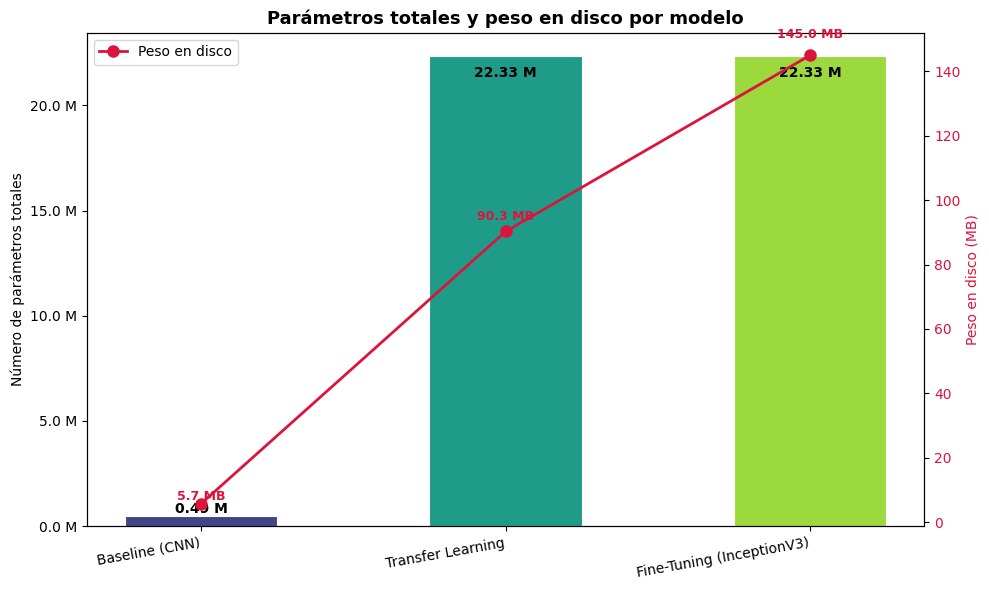

In [10]:
def count_params_detail(model):
  trainable     = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))
  non_trainable = int(np.sum([np.prod(v.shape) for v in model.non_trainable_weights]))
  return trainable, non_trainable, trainable + non_trainable

param_rows = []
for name, m in models.items():
  tr, ntr, tot = count_params_detail(m)
  param_rows.append({
    'Modelo'  : name,
    'Totales' : tot,
    'Entrenables'    : tr,
    'No entrenables' : ntr,
  })

params_df = pd.DataFrame(param_rows).set_index('Modelo')
display(
  params_df.style
    .format('{:,.0f}')
    .background_gradient(cmap='viridis', subset=['Totales'])
    .set_caption('Comparación de parámetros por modelo')
)

# ── Peso en disco de cada modelo ─────────────────────────────────────────────
model_files = {
  "Baseline (CNN)"           : TRAINING_DIR / "waste_classifier_baseline.keras",
  "Transfer Learning"        : TRAINING_DIR / "best_tl_model.keras",
  "Fine-Tuning (InceptionV3)": TRAINING_DIR / "best_ft_model.keras",
}
file_sizes_mb = [
  os.path.getsize(model_files[n]) / (1024 ** 2)
  for n in params_df.index
]

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 6))
cmap  = plt.cm.viridis
x     = np.arange(len(params_df))
width = 0.5

colors = [cmap(0.2), cmap(0.55), cmap(0.85)]
bars = ax1.bar(x, params_df['Totales'], width, color=colors, edgecolor='white', linewidth=0.8)

# Texto: total de parámetros sobre cada barra
for bar, val in zip(bars, params_df['Totales']):
  ax1.text(
    bar.get_x() + bar.get_width() / 2,
    bar.get_height() * 0.95,
    f'{val/1e6:.2f} M',
    ha='center', va='bottom', fontsize=10, fontweight='bold'
  )

ax1.set_xticks(x)
ax1.set_xticklabels(params_df.index, rotation=10, ha='right')
ax1.set_ylabel('Número de parámetros totales', fontsize=10)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1e6:.1f} M'))
ax1.set_title('Parámetros totales y peso en disco por modelo', fontweight='bold', fontsize=13)

# Eje secundario: peso en disco
ax2 = ax1.twinx()
ax2.plot(x, file_sizes_mb, color='crimson', marker='o', markersize=8,
     linewidth=2, label='Peso en disco')

# Texto: tamaño en MB sobre cada punto
for xi, mb in zip(x, file_sizes_mb):
  unit = 'MB' if mb >= 1 else 'KB'
  val_str = f'{mb:.1f} {unit}' if mb >= 1 else f'{mb*1024:.1f} KB'
  ax2.text(xi, mb * 1.03, val_str, ha='center', va='bottom',
       fontsize=9, color='crimson', fontweight='bold')

ax2.set_ylabel('Peso en disco (MB)', fontsize=10, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()


## 3.2 Métricas en el conjunto de prueba

In [12]:
import time

def get_preds(model, dataset):
    """Devuelve (y_true, y_pred) como arrays de índices de clase."""
    y_true, y_pred = [], []
    for imgs, lbls in dataset:
        preds = model.predict(imgs, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(np.argmax(lbls.numpy(), axis=1))
    return np.array(y_true), np.array(y_pred)

print("Generando predicciones en el conjunto de prueba…")
# Baseline usa test_ds (224×224); TL y FT usan test_ds_299 (299×299)
start = time.time()
y_true_bl, y_pred_bl = get_preds(baseline_model, test_ds)
print(f"  ✓ Predicciones de Baseline (CNN) en {time.time() - start:.2f}s")

start = time.time()
y_true_tl, y_pred_tl = get_preds(tl_model, test_ds_299)
print(f"  ✓ Predicciones de Transfer Learning en {time.time() - start:.2f}s")

start = time.time()
y_true_ft, y_pred_ft = get_preds(ft_model, test_ds_299)
print(f"  ✓ Predicciones de Fine-Tuning (InceptionV3) en {time.time() - start:.2f}s")

# Diccionario unificado para uso posterior
model_results = {
    "Baseline (CNN)"          : (y_true_bl, y_pred_bl),
    "Transfer Learning"       : (y_true_tl, y_pred_tl),
    "Fine-Tuning (InceptionV3)": (y_true_ft, y_pred_ft),
}

Generando predicciones en el conjunto de prueba…
  ✓ Predicciones de Baseline (CNN) en 3.74s
  ✓ Predicciones de Transfer Learning en 6.13s
  ✓ Predicciones de Fine-Tuning (InceptionV3) en 5.32s


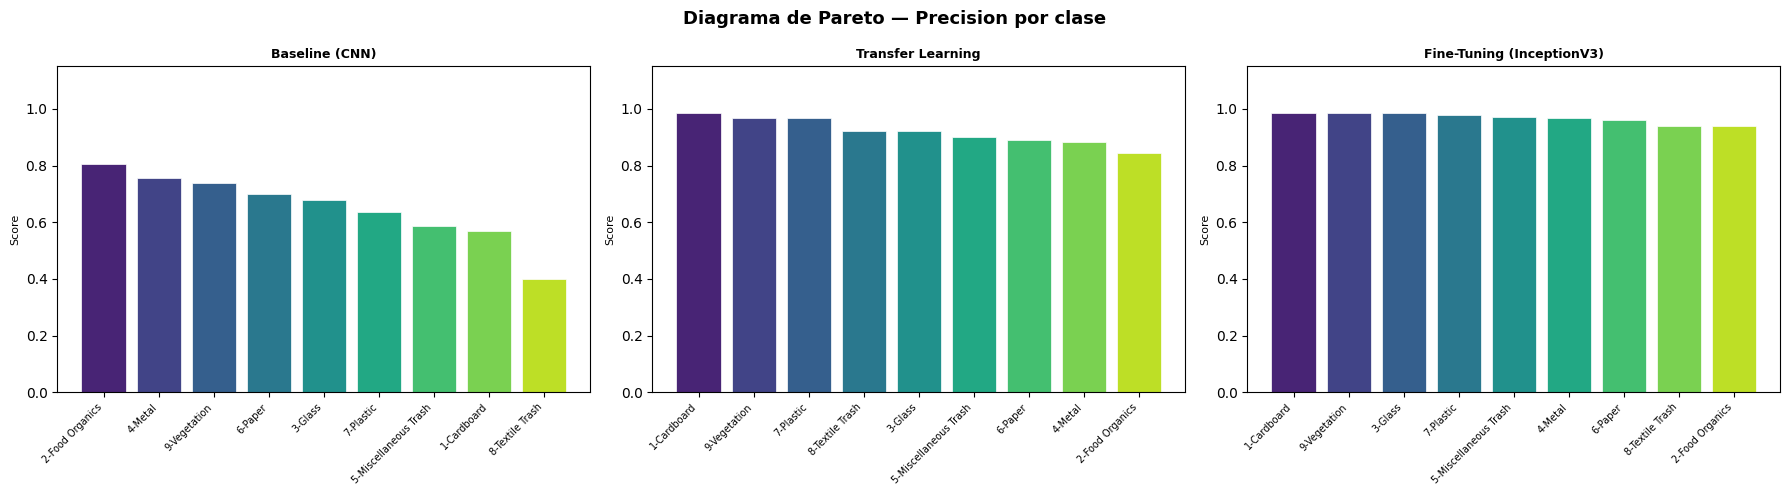

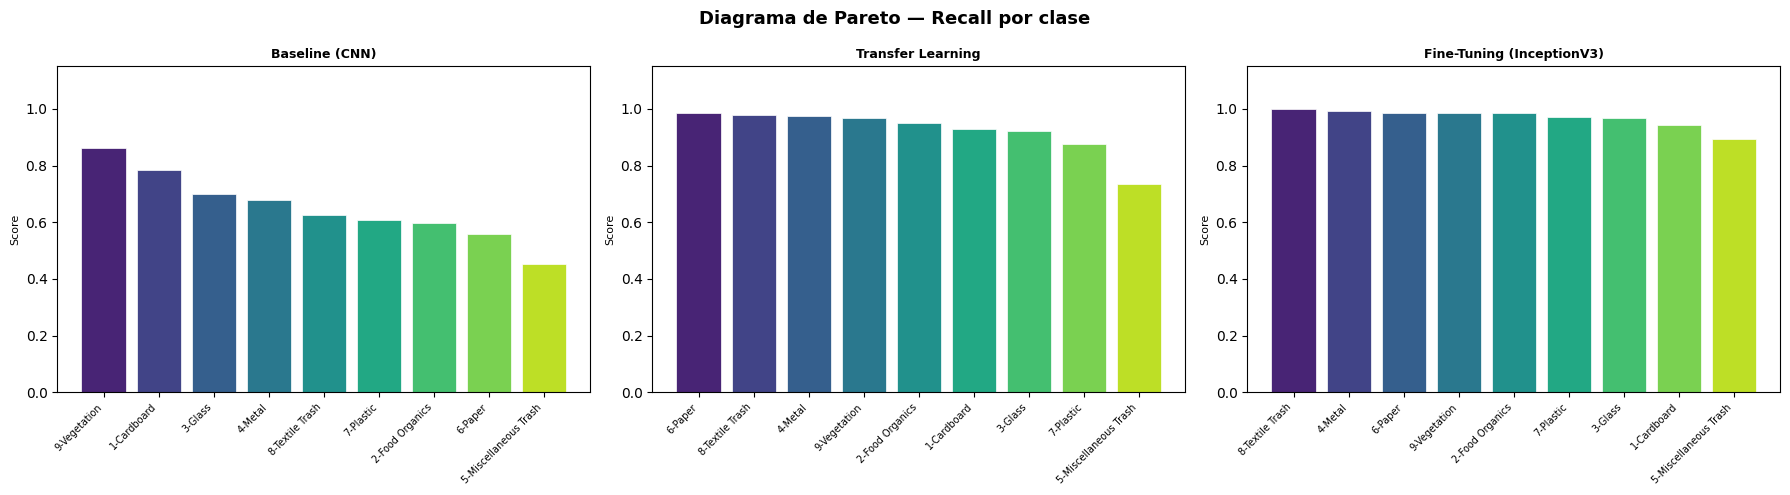

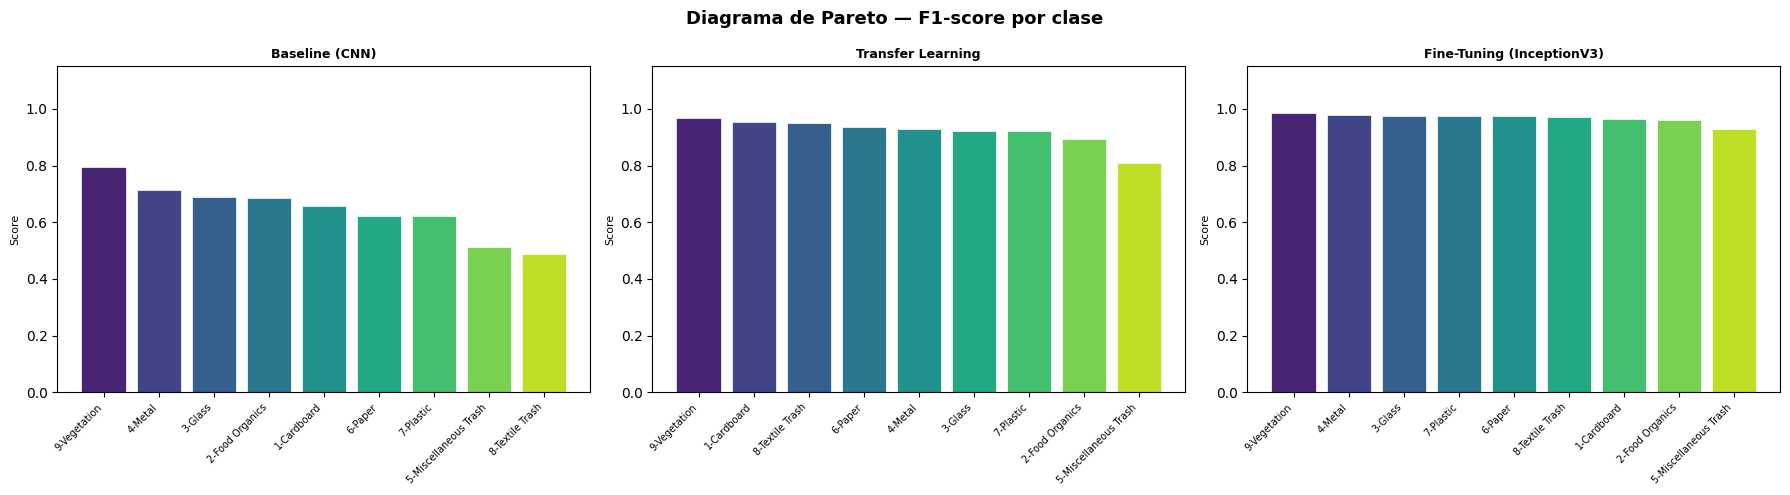

In [13]:
def plot_pareto(ax, values, class_names, title, palette="viridis"):
  idx_s   = np.argsort(values)[::-1]
  vals_s  = np.array(values)[idx_s]
  names_s = [class_names[i] for i in idx_s]

  colors = sns.color_palette(palette, n_colors=len(vals_s))
  ax.bar(range(len(vals_s)), vals_s, color=colors, edgecolor='white', linewidth=0.5)
  ax.set_xticks(range(len(vals_s)))
  ax.set_xticklabels(names_s, rotation=45, ha='right', fontsize=7)
  ax.set_ylim(0, 1.15)
  ax.set_title(title, fontsize=9, fontweight='bold')
  ax.set_ylabel('Score', fontsize=8)

metric_labels = ['Precision', 'Recall', 'F1-score']

for metric_idx, metric_name in enumerate(metric_labels):
  fig, axes = plt.subplots(1, 3, figsize=(18, 5))
  fig.suptitle(f'Diagrama de Pareto — {metric_name} por clase', fontsize=13, fontweight='bold')

  for ax, (model_name, (y_t, y_p)) in zip(axes, model_results.items()):
    prec, rec, f1, _ = precision_recall_fscore_support(
      y_t, y_p, average=None, labels=range(NUM_CLASSES), zero_division=0
    )
    metric_vals = [prec, rec, f1][metric_idx]
    plot_pareto(ax, metric_vals, categories, model_name)

  plt.tight_layout()
  plt.show()


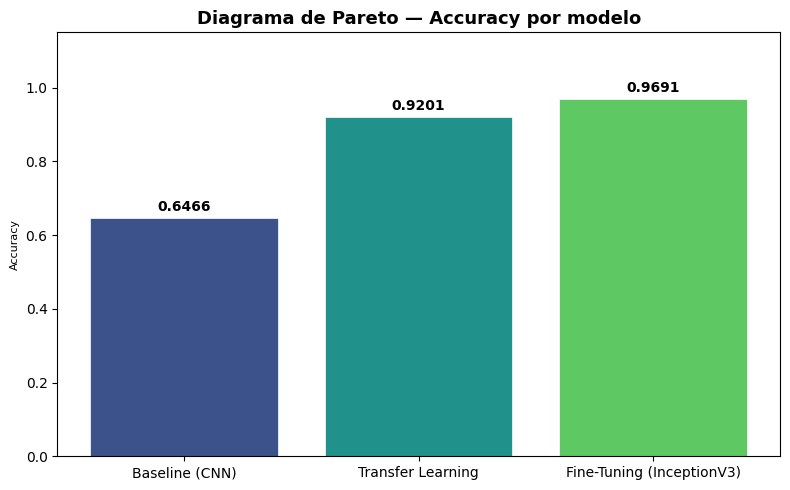

In [14]:
# Diagrama pareto para Accuracy por modelo
accuracy_scores = {name: accuracy_score(*results) for name, results in model_results.items()}
fig, ax = plt.subplots(figsize=(8, 5))
model_names = list(accuracy_scores.keys())
accuracy_vals = list(accuracy_scores.values())
colors = sns.color_palette("viridis", n_colors=len(accuracy_vals))
bars = ax.bar(model_names, accuracy_vals, color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, accuracy_vals):
  ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
      f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_title('Diagrama de Pareto — Accuracy por modelo', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=8)
plt.tight_layout()
plt.show()

## 3.3 Matrices de confusión

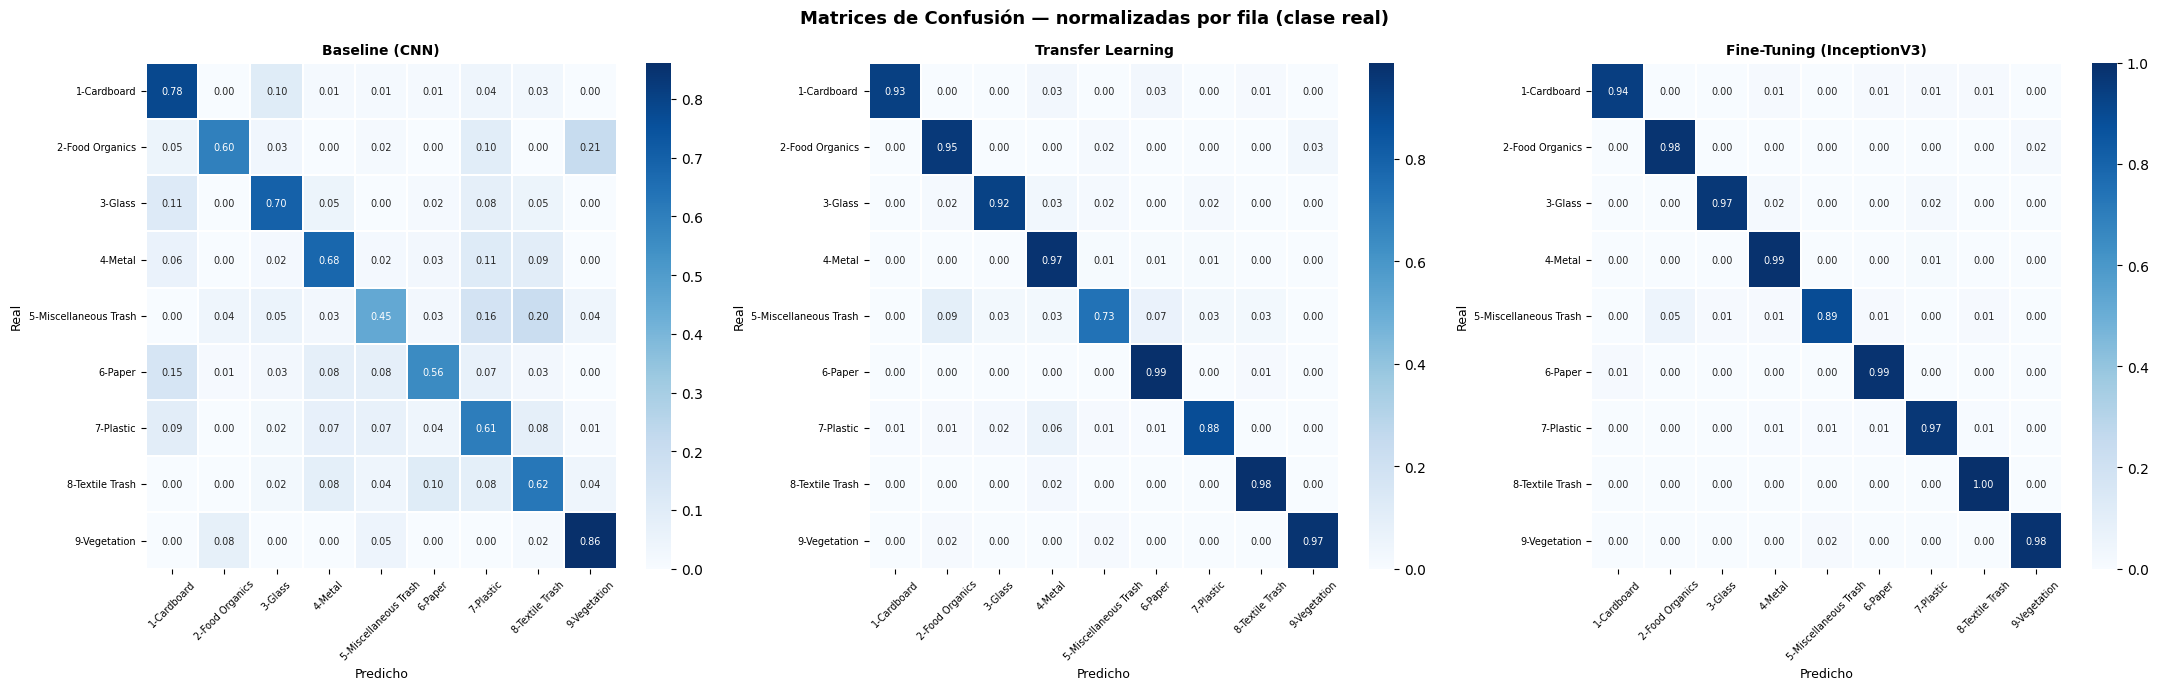

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Matrices de Confusión — normalizadas por fila (clase real)',
             fontsize=13, fontweight='bold')

for ax, (model_name, (y_t, y_p)) in zip(axes, model_results.items()):
    cm = confusion_matrix(y_t, y_p, normalize='true')
    sns.heatmap(
        cm,
        annot=True, fmt='.2f', cmap='Blues',
        xticklabels=categories, yticklabels=categories,
        ax=ax, cbar=True, linewidths=0.3,
        annot_kws={'size': 7}
    )
    ax.set_title(model_name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicho', fontsize=9)
    ax.set_ylabel('Real',     fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0,  labelsize=7)

plt.tight_layout()
plt.show()


## 3.4 Classification Report

In [16]:
for model_name, (y_t, y_p) in model_results.items():
    print(f"\n{'═'*65}")
    print(f"  {model_name}")
    print(f"{'═'*65}")

    report_dict = classification_report(
        y_t, y_p, target_names=categories,
        output_dict=True, zero_division=0
    )
    report_df = (
        pd.DataFrame(report_dict).T
        .loc[categories + ['accuracy', 'macro avg', 'weighted avg']]
        .round(4)
    )
    display(
        report_df.style
            .background_gradient(cmap='Blues',
                                 subset=pd.IndexSlice[categories, ['precision', 'recall', 'f1-score']])
            .format({'precision': '{:.4f}', 'recall': '{:.4f}',
                     'f1-score': '{:.4f}', 'support': '{:.0f}'}, na_rep='—')
            .set_caption(f'Classification Report — {model_name}')
    )
    # Versión texto
    print(classification_report(y_t, y_p, target_names=categories,
                                 digits=4, zero_division=0))



═════════════════════════════════════════════════════════════════
  Baseline (CNN)
═════════════════════════════════════════════════════════════════


,precision,recall,f1-score,support
1-Cardboard,0.5684,0.7826,0.6585,69
2-Food Organics,0.8043,0.5968,0.6852,62
3-Glass,0.6769,0.6984,0.6875,63
4-Metal,0.7547,0.6780,0.7143,118
5-Miscellaneous Trash,0.5862,0.4533,0.5113,75
6-Paper,0.7000,0.5600,0.6222,75
7-Plastic,0.6364,0.6087,0.6222,138
8-Textile Trash,0.4000,0.6250,0.4878,48
9-Vegetation,0.7368,0.8615,0.7943,65
accuracy,0.6466,0.6466,0.6466,1


                       precision    recall  f1-score   support

          1-Cardboard     0.5684    0.7826    0.6585        69
      2-Food Organics     0.8043    0.5968    0.6852        62
              3-Glass     0.6769    0.6984    0.6875        63
              4-Metal     0.7547    0.6780    0.7143       118
5-Miscellaneous Trash     0.5862    0.4533    0.5113        75
              6-Paper     0.7000    0.5600    0.6222        75
            7-Plastic     0.6364    0.6087    0.6222       138
      8-Textile Trash     0.4000    0.6250    0.4878        48
         9-Vegetation     0.7368    0.8615    0.7943        65

             accuracy                         0.6466       713
            macro avg     0.6515    0.6516    0.6426       713
         weighted avg     0.6622    0.6466    0.6472       713


═════════════════════════════════════════════════════════════════
  Transfer Learning
═════════════════════════════════════════════════════════════════


,precision,recall,f1-score,support
1-Cardboard,0.9846,0.9275,0.9552,69
2-Food Organics,0.8429,0.9516,0.8939,62
3-Glass,0.9206,0.9206,0.9206,63
4-Metal,0.8846,0.9746,0.9274,118
5-Miscellaneous Trash,0.9016,0.7333,0.8088,75
6-Paper,0.8916,0.9867,0.9367,75
7-Plastic,0.9680,0.8768,0.9202,138
8-Textile Trash,0.9216,0.9792,0.9495,48
9-Vegetation,0.9692,0.9692,0.9692,65
accuracy,0.9201,0.9201,0.9201,1


                       precision    recall  f1-score   support

          1-Cardboard     0.9846    0.9275    0.9552        69
      2-Food Organics     0.8429    0.9516    0.8939        62
              3-Glass     0.9206    0.9206    0.9206        63
              4-Metal     0.8846    0.9746    0.9274       118
5-Miscellaneous Trash     0.9016    0.7333    0.8088        75
              6-Paper     0.8916    0.9867    0.9367        75
            7-Plastic     0.9680    0.8768    0.9202       138
      8-Textile Trash     0.9216    0.9792    0.9495        48
         9-Vegetation     0.9692    0.9692    0.9692        65

             accuracy                         0.9201       713
            macro avg     0.9205    0.9244    0.9202       713
         weighted avg     0.9227    0.9201    0.9190       713


═════════════════════════════════════════════════════════════════
  Fine-Tuning (InceptionV3)
═════════════════════════════════════════════════════════════════


,precision,recall,f1-score,support
1-Cardboard,0.9848,0.9420,0.9630,69
2-Food Organics,0.9385,0.9839,0.9606,62
3-Glass,0.9839,0.9683,0.9760,63
4-Metal,0.9669,0.9915,0.9791,118
5-Miscellaneous Trash,0.9710,0.8933,0.9306,75
6-Paper,0.9610,0.9867,0.9737,75
7-Plastic,0.9781,0.9710,0.9745,138
8-Textile Trash,0.9412,1.0000,0.9697,48
9-Vegetation,0.9846,0.9846,0.9846,65
accuracy,0.9691,0.9691,0.9691,1


                       precision    recall  f1-score   support

          1-Cardboard     0.9848    0.9420    0.9630        69
      2-Food Organics     0.9385    0.9839    0.9606        62
              3-Glass     0.9839    0.9683    0.9760        63
              4-Metal     0.9669    0.9915    0.9791       118
5-Miscellaneous Trash     0.9710    0.8933    0.9306        75
              6-Paper     0.9610    0.9867    0.9737        75
            7-Plastic     0.9781    0.9710    0.9745       138
      8-Textile Trash     0.9412    1.0000    0.9697        48
         9-Vegetation     0.9846    0.9846    0.9846        65

             accuracy                         0.9691       713
            macro avg     0.9678    0.9690    0.9680       713
         weighted avg     0.9695    0.9691    0.9690       713



# 4. Entrenamiento final del modelo de producción

Reentrenamiento del mejor modelo (**Fine-Tuning InceptionV3**) con la **totalidad** de los datos disponibles, reservando únicamente el **10 %** para validación. El modelo resultante se guarda como `model_prd.keras`.

| Parámetro | Valor |
|---|---|
| Dataset | `realwaste_mod` (completo) |
| Partición | 90 % entrenamiento / 10 % validación |
| Arquitectura | InceptionV3 (fine-tuning) |
| Hiperparámetros | Extraídos de `best_ft_model.keras` |

In [ ]:
# ── Carga de datos realwaste_mod (todos) ──────────────────────────────────────
_root_mod = next(
    (p for p in [_cwd_eval] + list(_cwd_eval.parents) if (p / "realwaste_mod.dvc").exists()),
    _cwd_eval
)
path_mod = str(_root_mod / "realwaste_mod")

rows_mod = []
for category in categories:
    cat_dir = os.path.join(path_mod, category)
    for img_name in os.listdir(cat_dir):
        rows_mod.append({'image_path': os.path.join(cat_dir, img_name), 'label': category})

df_mod = pd.DataFrame(rows_mod)
print(f"Total imágenes (realwaste_mod) : {len(df_mod)}")
print(f"Distribución por clase:")
print(df_mod['label'].value_counts().to_string())

# ── Partición 90/10 estratificada (sin conjunto de prueba) ───────────────────
train_prd_df, val_prd_df = train_test_split(
    df_mod, test_size=0.10, stratify=df_mod['label'], random_state=SEED
)
print(f"\nEntrenamiento producción : {len(train_prd_df)} imágenes")
print(f"Validación  producción   : {len(val_prd_df)}  imágenes")

# ── Pipelines de datos a 299×299 ─────────────────────────────────────────────
def build_prd_ds(dataframe, shuffle=False):
    paths     = dataframe['image_path'].values
    labels_oh = tf.keras.utils.to_categorical(
        dataframe['label'].map(label_to_index).values, NUM_CLASSES
    )
    ds = tf.data.Dataset.from_tensor_slices((paths, labels_oh))
    ds = ds.map(load_and_preprocess_299, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=2048, seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_prd_ds = build_prd_ds(train_prd_df, shuffle=True)
val_prd_ds   = build_prd_ds(val_prd_df,   shuffle=False)

# ── Pesos de clase para el conjunto de producción ────────────────────────────
_prd_labels = train_prd_df['label'].map(label_to_index).values
class_weight_prd = dict(enumerate(
    compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=_prd_labels)
))
print("\nPesos de clase (producción):")
for lbl, idx in sorted(label_to_index.items(), key=lambda x: x[1]):
    print(f"  {lbl:<25s}: {class_weight_prd[idx]:.4f}")


Total imágenes (realwaste_mod) : 4751
Distribución por clase:
label
7-Plastic                921
4-Metal                  790
6-Paper                  500
5-Miscellaneous Trash    495
1-Cardboard              460
9-Vegetation             436
3-Glass                  420
2-Food Organics          411
8-Textile Trash          318

Entrenamiento producción : 4275 imágenes
Validación  producción   : 476  imágenes

Pesos de clase (producción):
  1-Cardboard              : 1.1473
  2-Food Organics          : 1.2838
  3-Glass                  : 1.2566
  4-Metal                  : 0.6681
  5-Miscellaneous Trash    : 1.0674
  6-Paper                  : 1.0556
  7-Plastic                : 0.5730
  8-Textile Trash          : 1.6608
  9-Vegetation             : 1.2117


In [ ]:
def apply_finetune_prd(tl_model_path, learning_rate, layers_to_unfreeze):
    """Carga best_tl_model y descongela las últimas N capas del backbone InceptionV3."""
    model = tf.keras.models.load_model(tl_model_path)
    base  = next(layer for layer in model.layers if isinstance(layer, tf.keras.Model))

    base.trainable = True
    for layer in base.layers[:-layers_to_unfreeze]:
        layer.trainable = False
    for layer in base.layers[-layers_to_unfreeze:]:
        layer.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ── Extraer hiperparámetros del modelo FT guardado ───────────────────────────
_base_ft      = next(layer for layer in ft_model.layers if isinstance(layer, tf.keras.Model))
BEST_UNFREEZE = int(sum(1 for l in _base_ft.layers if l.trainable))
BEST_LR_FT    = float(ft_model.optimizer.get_config().get('learning_rate', 1e-5))

print(f"Hiperparámetros extraídos de best_ft_model:")
print(f"  Capas del backbone descongeladas : {BEST_UNFREEZE}")
print(f"  Learning rate inicial            : {BEST_LR_FT:.2e}")

# ── Construir modelo de producción ───────────────────────────────────────────
TL_PATH   = str(TRAINING_DIR / "best_tl_model.keras")
model_prd = apply_finetune_prd(TL_PATH, BEST_LR_FT, BEST_UNFREEZE)

tr_prd, ntr_prd, tot_prd = count_params_detail(model_prd)
print(f"\nParámetros del modelo de producción:")
print(f"  Totales          : {tot_prd:>12,}")
print(f"  Entrenables      : {tr_prd:>12,}")
print(f"  No entrenables   : {ntr_prd:>12,}")

# ── Callbacks ────────────────────────────────────────────────────────────────
PRD_MODEL_PATH = str(TRAINING_DIR / "model_prd.keras")
prd_callbacks  = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        PRD_MODEL_PATH, monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
]

# ── Entrenamiento ─────────────────────────────────────────────────────────────
print("\nEntrenando modelo de producción (90/10, hasta 30 épocas)…")
prd_history = model_prd.fit(
    train_prd_ds,
    validation_data=val_prd_ds,
    epochs=30,
    callbacks=prd_callbacks,
    class_weight=class_weight_prd,
    verbose=1
)

# Guardar modelo final (asegura que se guarda incluso si ModelCheckpoint ya lo hizo)
model_prd.save(PRD_MODEL_PATH)
print(f"\nModelo de producción guardado en: {PRD_MODEL_PATH}")


Hiperparámetros extraídos de best_ft_model:
  Capas del backbone descongeladas : 51
  Learning rate inicial            : 5.00e-05

Parámetros del modelo de producción:
  Totales          :   22,330,665
  Entrenables      :    8,143,049
  No entrenables   :   14,187,616

Entrenando modelo de producción (90/10, hasta 30 épocas)…
Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.8562 - loss: 0.4166
Epoch 1: val_accuracy improved from None to 0.90546, saving model to /content/training/model_prd.keras

Epoch 1: finished saving model to /content/training/model_prd.keras
134/134 ━━━━━━━━━━━━━━━━━━━━ 81s 410ms/step - accuracy: 0.8664 - loss: 0.3875 - val_accuracy: 0.9055 - val_loss: 0.3067 - learning_rate: 5.0000e-05
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.9557 - loss: 0.1145
Epoch 2: val_accuracy improved from 0.90546 to 0.92647, saving model to /content/training/model_prd.keras

Epoch 2: finished saving model to /content/training/model_prd.keras
